In [1]:
import pandas as pd
import numpy as np

In [ ]:
#Lectura de csv
df = pd.read_csv("../data/processed/netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
#dimeciones del dataframe
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
#tipos de datos 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [13]:
#separar el numero de la letra
df[['id_letra', 'id_numero']] = df['show_id'].str.extract(r'([a-zA-Z]+)(\d+)')

In [15]:
df['id_numero'] = df['id_numero'].astype(int)

In [16]:
df = df.drop(columns=['show_id'])

In [18]:
df = df.drop(columns=['id_letra'])

In [27]:
cols = ['id_numero'] + [col for col in df.columns if col != 'id_numero']
df = df[cols]

In [28]:
df.head()

,id_numero,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [30]:
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_numero     8807 non-null   int64         
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 825.8+ KB


## Limpieza

In [47]:
# 1. Extraemos el número y el texto por separado usando Regex
# (\d+) busca los números, (\s\w+) busca el espacio y la palabra (min o Seasons)
extracted = df['duration'].str.extract(r'(?P<value>\d+)\s(?P<unit>\w+)')

In [36]:
# 2. Convertimos el valor a numérico
extracted['value'] = pd.to_numeric(extracted['value'])


In [40]:
# 3. Creamos dos columnas nuevas basadas en la unidad
df['duration_minutes'] = extracted.apply(
    lambda x: x['value'] if isinstance(x['unit'], str) and 'min' in x['unit'] else np.nan,
    axis=1
)
df['duration_seasons'] = extracted.apply(
    lambda x: x['value'] if isinstance(x['unit'], str) and 'Season' in x['unit'] else np.nan,
    axis=1
)

# Opcional: Rellenar con 0 los que no aplican para poder operar
df['duration_minutes'] = df['duration_minutes'].fillna(0).astype(int)
df['duration_seasons'] = df['duration_seasons'].fillna(0).astype(int)

In [41]:
df.head()

,id_numero,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,0
1,2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,2
2,3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,1
3,4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,1
4,5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,2


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_numero         8807 non-null   int64         
 1   type              8807 non-null   object        
 2   title             8807 non-null   object        
 3   director          6173 non-null   object        
 4   cast              7982 non-null   object        
 5   country           7976 non-null   object        
 6   date_added        8709 non-null   datetime64[ns]
 7   release_year      8807 non-null   int64         
 8   rating            8803 non-null   object        
 9   duration          8804 non-null   object        
 10  listed_in         8807 non-null   object        
 11  description       8807 non-null   object        
 12  duration_minutes  8807 non-null   int64         
 13  duration_seasons  8807 non-null   int64         
dtypes: datetime64[ns](1), in

## Analisis descriptivo

In [43]:
df.describe()

,id_numero,date_added,release_year,duration_minutes,duration_seasons
count,8807.000000,8709,8807.000000,8807.000000,8807.000000
mean,4404.000000,2019-05-23 01:45:29.452290816,2014.180198,69.286817,0.536278
min,1.000000,2008-01-01 00:00:00,1925.000000,0.000000,0.000000
25%,2202.500000,2018-04-20 00:00:00,2013.000000,0.000000,0.000000
50%,4404.000000,2019-07-12 00:00:00,2017.000000,88.000000,0.000000
75%,6605.500000,2020-08-26 00:00:00,2019.000000,106.000000,1.000000
max,8807.000000,2021-09-25 00:00:00,2021.000000,312.000000,17.000000
std,2542.506244,NaN,8.819312,51.534755,1.191620


In [44]:
#visaulizacion de datos
import seaborn as sns
import matplotlib.pyplot as plt

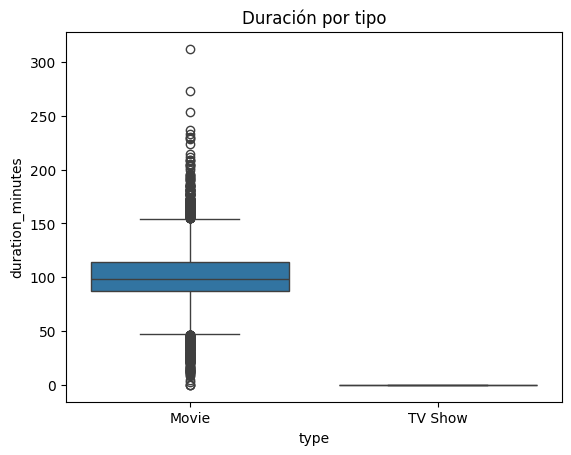

In [46]:
#boxplot
sns.boxplot(x='type', y='duration_minutes', data=df)
plt.title('Duración por tipo')
plt.show()

## Datos Faltantes

In [48]:
#Detectar los NA
df.isna().sum()

id_numero              0
type                   0
title                  0
director            2634
cast                 825
country              831
date_added            98
release_year           0
rating                 4
duration               3
listed_in              0
description            0
duration_minutes       0
duration_seasons       0
dtype: int64

In [49]:
df['director'] = df['director'].fillna('Unknown')

In [51]:
df['cast'] = df['cast'].fillna('Unknown')

In [53]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [57]:
df['date_added'] = df['date_added'].fillna(method='ffill')

C:\Users\rqm\AppData\Local\Temp\ipykernel_2328\3385547354.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date_added'] = df['date_added'].fillna(method='ffill')


## Decision

¿qUE HACER CON LOS FALTANTES?

In [59]:
df['duration'] = df['duration'].fillna('Unknown')

In [58]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [60]:
#Detectar los NA
df.isna().sum()

id_numero           0
type                0
title               0
director            0
cast                0
country             0
date_added          0
release_year        0
rating              0
duration            0
listed_in           0
description         0
duration_minutes    0
duration_seasons    0
dtype: int64

In [64]:
df.head(10)

,id_numero,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,0
1,2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,2
2,3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,1
3,4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,1
4,5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,2
5,6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,0,1
6,7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91,0
7,8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125,0
8,9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,0,9
9,10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104,0


## Valores atipicos

In [62]:
Q1 = df['duration_minutes'].quantile(0.25)
Q3 = df['duration_minutes'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [63]:
outliers = df[(df['duration_minutes'] < limite_inferior) | 
              (df['duration_minutes'] > limite_superior)]

outliers

,id_numero,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
717,718,Movie,Headspace: Unwind Your Mind,Unknown,"Andy Puddicombe, Evelyn Lewis Prieto, Ginger D...",United States,2021-06-15,2021,TV-G,273 min,Documentaries,"Do you want to relax, meditate or sleep deeply...",273,0
4253,4254,Movie,Black Mirror: Bandersnatch,Unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",312,0


### Los ouliers son un error de captura 

Black Mirror: Bandersnatch



In [65]:
outliers.shape

(2, 14)

In [66]:
from scipy.stats import zscore

df['zscore'] = zscore(df['duration_minutes'].dropna())

outliers = df[df['zscore'].abs() > 3]

In [67]:
df = df[(df['duration_minutes'] >= limite_inferior) & 
        (df['duration_minutes'] <= limite_superior)]

<Axes: xlabel='type', ylabel='duration_minutes'>

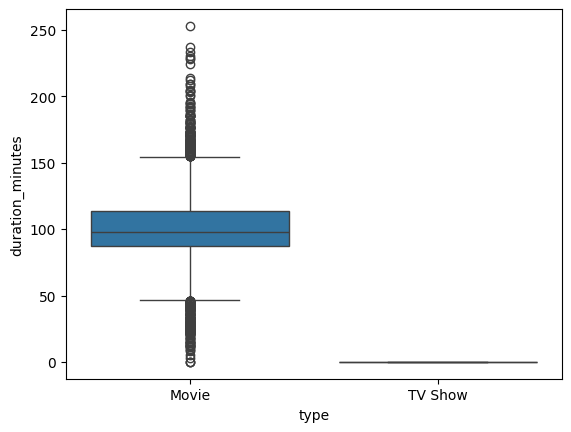

In [68]:
sns.boxplot(x='type', y='duration_minutes', data=df)

#### ¿Porque borrar los outliers?

“Analicé los valores atípicos y determiné que representaban casos reales, por lo que decidí mantenerlos para no perder información relevante”

## Analisis de Corekacion

In [75]:
#Ver corelacion
df.corr(numeric_only=True)

,id_numero,release_year,duration_minutes,duration_seasons,zscore,type_encoded
id_numero,1.000000,-0.246623,0.104419,-0.108564,0.104419,-0.130611
release_year,-0.246623,1.000000,-0.249085,0.100171,-0.249085,0.181818
duration_minutes,0.104419,-0.249085,1.000000,-0.606008,1.000000,-0.889591
duration_seasons,-0.108564,0.100171,-0.606008,1.000000,-0.606008,0.681221
zscore,0.104419,-0.249085,1.000000,-0.606008,1.000000,-0.889591
type_encoded,-0.130611,0.181818,-0.889591,0.681221,-0.889591,1.000000


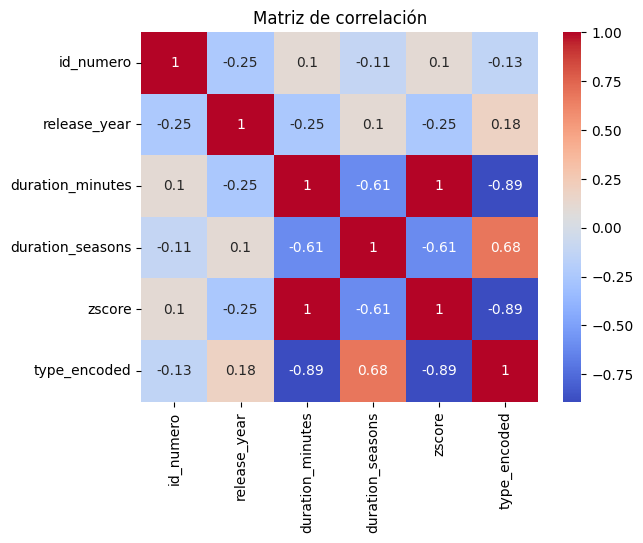

In [76]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

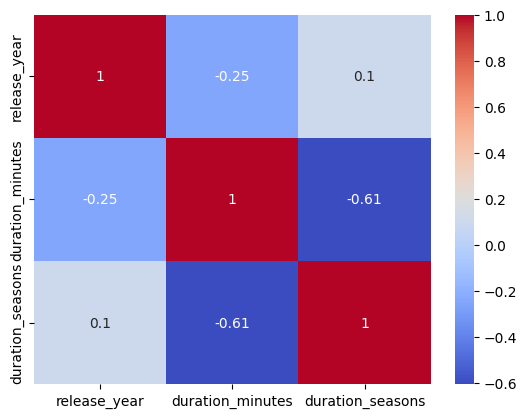

In [77]:
corr = df[['release_year', 'duration_minutes', 'duration_seasons']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [78]:
df['type_encoded'] = df['type'].map({'Movie': 0, 'TV Show': 1})

In [79]:
df[['type_encoded', 'duration_minutes']].corr()

,type_encoded,duration_minutes
type_encoded,1.000000,-0.889591
duration_minutes,-0.889591,1.000000


Se encontró una correlación negativa moderada (-0.60) entre duración en minutos y número de temporadas, lo cual refleja la diferencia estructural entre películas y series. Además, no se observó una relación significativa entre el año de lanzamiento y la duración del contenido.

In [ ]:
#Solo peliculas
movies = df[df['type'] == 'Movie']
movies[['release_year', 'duration_minutes']].corr()

,release_year,duration_minutes
release_year,1.000000,-0.208856
duration_minutes,-0.208856,1.000000


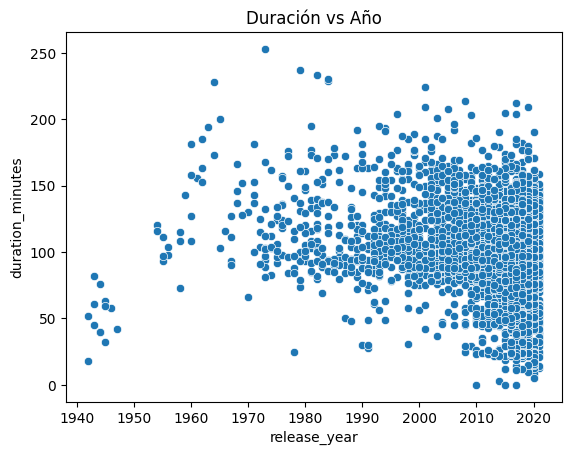

In [82]:
sns.scatterplot(x='release_year', y='duration_minutes', data=movies)
plt.title('Duración vs Año')
plt.show()

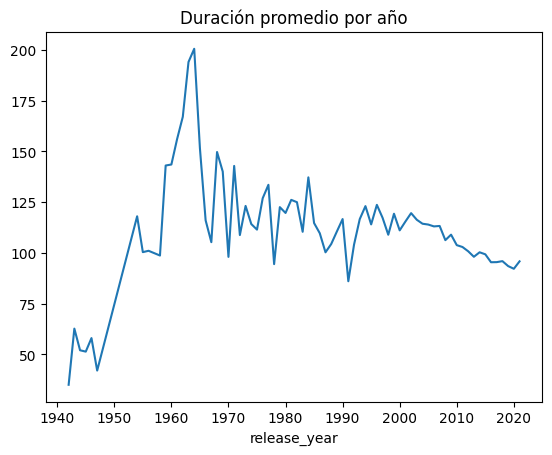

In [83]:
movies.groupby('release_year')['duration_minutes'].mean().plot()
plt.title('Duración promedio por año')
plt.show()

>> Se observa una ligera tendencia a que las películas más recientes tengan menor duración; sin embargo, la correlación es débil (-0.20), lo que indica que el año de lanzamiento no es un factor determinante en la duración.

In [ ]:
#Solo series
tv = df[df['type'] == 'TV Show']
tv[['release_year', 'duration_seasons']].corr()

,release_year,duration_seasons
release_year,1.000000,-0.090194
duration_seasons,-0.090194,1.000000


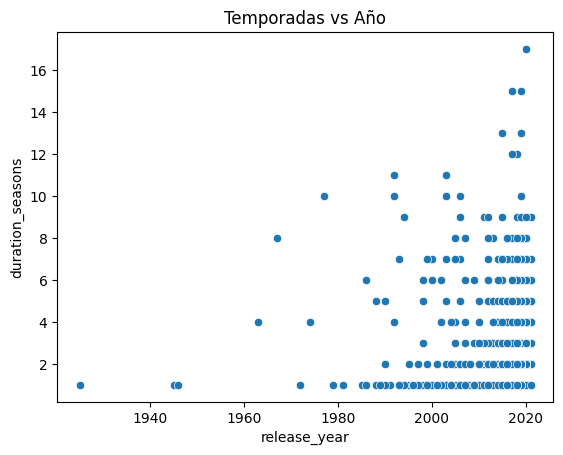

In [84]:
sns.scatterplot(x='release_year', y='duration_seasons', data=tv)
plt.title('Temporadas vs Año')
plt.show()

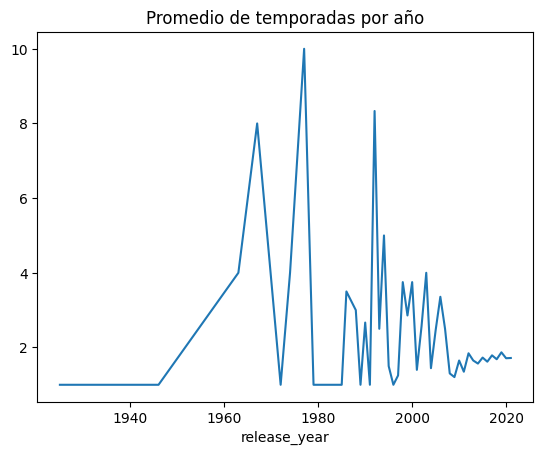

In [85]:
tv.groupby('release_year')['duration_seasons'].mean().plot()
plt.title('Promedio de temporadas por año')
plt.show()

> No se encontró una relación significativa entre el año de lanzamiento y el número de temporadas (-0.09), lo que sugiere que la duración de las series en términos de temporadas es independiente del tiempo.